### Cleaning the seperate folders

In [1]:
!pip install pillow imagehash opencv-python tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 13.9 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 16.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [imagehash]/4 [opencv-python]


In [2]:
!pip install cv2

ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)
ERROR: No matching distribution found for cv2


In [ ]:
import cv2
import hashlib
from pathlib import Path
from PIL import Image
import imagehash
import shutil

# CONFIG
INPUT_DIR = Path("/Users/adrianpothanah/Plant Disease Management System/CST3990-Plant-Disease-Management-System/Hibiscus Healthy")  # CHANGE per folder
OUTPUT_DIR = Path("HIBISCUS_TEST")  # CHANGE per folder

BLUR_THRESHOLD = 40
PHASH_THRESHOLD = 10

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# HELPERS

def is_blurry(path):
    img = cv2.imread(str(path))
    if img is None:
        return True
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var() < BLUR_THRESHOLD

def file_hash(path):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        h.update(f.read())
    return h.hexdigest()

def phash(path):
    try:
        return imagehash.phash(Image.open(path).convert("RGB"))
    except:
        return None

# CLEANING

seen_hashes = set()
phashes = []

kept = 0

for file in INPUT_DIR.iterdir():
    if file.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
        continue

    # remove blurry
    if is_blurry(file):
        continue

    # remove exact duplicates
    h = file_hash(file)
    if h in seen_hashes:
        continue
    seen_hashes.add(h)

    # remove near duplicates
    p = phash(file)
    if p is None:
        continue

    duplicate = False
    for existing in phashes:
        if p - existing <= PHASH_THRESHOLD:
            duplicate = True
            break

    if duplicate:
        continue

    phashes.append(p)

    # save clean image
    new_name = f"img_{kept}.jpg"
    shutil.copy(file, OUTPUT_DIR / new_name)
    kept += 1

print(f"Cleaned images: {kept}")

Cleaned images: 307


In [30]:
import cv2
import hashlib
import shutil
from pathlib import Path
from PIL import Image

INPUT_DIR = Path("/Users/adrianpothanah/Plant Disease Management System/CST3990-Plant-Disease-Management-System/rose/Rose_Rust")
OUTPUT_DIR = Path("cleaned_data/rose/rust")

BLUR_THRESHOLD = 25  # lighter blur filtering

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except:
        return False

def is_blurry(path, threshold=BLUR_THRESHOLD):
    img = cv2.imread(str(path))
    if img is None:
        return True
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    score = cv2.Laplacian(gray, cv2.CV_64F).var()
    return score < threshold

def file_hash(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

seen_hashes = set()
kept = 0

for file in INPUT_DIR.iterdir():
    if file.suffix.lower() not in [".jpg", ".jpeg", ".png", ".webp", ".bmp"]:
        continue

    if not is_valid_image(file):
        continue

    if is_blurry(file):
        continue

    h = file_hash(file)
    if h in seen_hashes:
        continue
    seen_hashes.add(h)

    ext = file.suffix.lower()
    new_name = f"hibiscus_leaf_spot_{kept:04d}{ext}"
    shutil.copy2(file, OUTPUT_DIR / new_name)
    kept += 1

print("Kept images:", kept)

Kept images: 2450


### Script to select images from Plant Village before merging with Plant Doc

In [ ]:
import os
import random
import shutil
from pathlib import Path

import cv2
import numpy as np
from PIL import Image

# CONFIG
INPUT_DIR = Path("/Users/adrianpothanah/Plant Disease Management System/CST3990-Plant-Disease-Management-System/cleaned_data/PlantVillage/Potato/healthy")  # CHANGE per folder
OUTPUT_DIR = Path("selected_data/PlantVillage/Potato/healthy")  # CHANGE per folder

FINAL_COUNT = 328     # number you want to keep
TOP_POOL_RATIO = 0.70      # keep top 70% by quality, then sample randomly from them
SEED = 42

ALLOWED_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

random.seed(SEED)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# IMAGE QUALITY FUNCTIONS

def is_valid_image(path: Path) -> bool:
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

def image_quality_score(path: Path) -> float:
    """
    Higher score = better image.
    Uses:
    - resolution
    - sharpness (Laplacian variance)
    - brightness penalty if too dark/too bright
    """
    img = cv2.imread(str(path))
    if img is None:
        return -1

    h, w = img.shape[:2]
    resolution_score = h * w

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    sharpness_score = cv2.Laplacian(gray, cv2.CV_64F).var()

    brightness = np.mean(gray)

    # Penalize extreme brightness
    brightness_penalty = 0
    if brightness < 40:
        brightness_penalty = 0.5
    elif brightness > 220:
        brightness_penalty = 0.5

    # Normalize rough contributions
    score = (
        (resolution_score / 1_000_000) * 2.0 +   # resolution contribution
        (sharpness_score / 100.0) * 3.0          # sharpness contribution
    )

    score = score * (1 - brightness_penalty)
    return score

# COLLECT + SCORE IMAGES

all_images = [
    p for p in INPUT_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in ALLOWED_EXTS
]

scored_images = []

for img_path in all_images:
    if not is_valid_image(img_path):
        continue
    score = image_quality_score(img_path)
    if score >= 0:
        scored_images.append((img_path, score))

if not scored_images:
    raise ValueError("No valid images found.")

# Sort from best to worst
scored_images.sort(key=lambda x: x[1], reverse=True)

# KEEP TOP QUALITY POOL

top_pool_size = max(FINAL_COUNT, int(len(scored_images) * TOP_POOL_RATIO))
top_pool = scored_images[:top_pool_size]

# Randomly sample from top-quality pool
if len(top_pool) <= FINAL_COUNT:
    selected = top_pool
else:
    selected = random.sample(top_pool, FINAL_COUNT)

# Optional: sort selected again by score just for reporting
selected.sort(key=lambda x: x[1], reverse=True)

# COPY + RENAME

for i, (img_path, score) in enumerate(selected, start=1):
    new_name = f"{INPUT_DIR.name.lower()}_{i:04d}{img_path.suffix.lower()}"
    shutil.copy2(img_path, OUTPUT_DIR / new_name)

# REPORT

print(f"Total valid images found: {len(scored_images)}")
print(f"Top quality pool size: {len(top_pool)}")
print(f"Final selected images: {len(selected)}")
print(f"Saved to: {OUTPUT_DIR.resolve()}")

print("\nTop 10 selected image scores:")
for img_path, score in selected[:10]:
    print(f"{img_path.name} -> {score:.2f}")

Total valid images found: 676
Top quality pool size: 473
Final selected images: 328
Saved to: /Users/adrianpothanah/Plant Disease Management System/CST3990-Plant-Disease-Management-System/selected_data/PlantVillage/Potato/healthy

Top 10 selected image scores:
pd_img_13.jpg -> 397.90
pd_img_108.jpg -> 397.87
pd_img_79.jpg -> 377.40
pd_img_94.jpg -> 364.74
pd_img_126.jpg -> 349.92
pd_img_84.jpg -> 346.95
pd_img_51.jpg -> 342.44
pd_img_104.jpg -> 335.14
pd_img_52.jpg -> 328.22
pd_img_59.jpg -> 328.03


### Merging of plant doc and plant village images

In [ ]:
import os
import shutil
from pathlib import Path

# CONFIG
FOLDER_1 = Path("/Users/adrianpothanah/Plant Disease Management System/CST3990-Plant-Disease-Management-System/selected_data/PlantVillage/Tomato/yellow_leaf_curl_virus")  # CHANGE per folder
FOLDER_2 = Path("/Users/adrianpothanah/Plant Disease Management System/CST3990-Plant-Disease-Management-System/cleaned_data/PlantDoc/Tomato/yellow_leaf_curl_virus")

OUTPUT_FOLDER = Path("plant_disease_dataset/Tomato/Yellow_leaf_curl_virus")  # CHANGE per folder

ALLOWED_EXTS = (".jpg", ".jpeg", ".png")

OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

# GET CLASS NAME FROM OUTPUT FOLDER

plant_name = OUTPUT_FOLDER.parent.name.lower().replace(" ", "_")
class_name = OUTPUT_FOLDER.name.lower().replace(" ", "_")

prefix = f"{plant_name}_{class_name}"  # e.g. potato_healthy

# FUNCTION TO COPY + RENAME FILES

def copy_images(src_folder, start_index):
    count = 0
    index = start_index

    for file in os.listdir(src_folder):
        if file.lower().endswith(ALLOWED_EXTS):
            src = src_folder / file

            new_name = f"{prefix}_{index:04d}{Path(file).suffix.lower()}"
            dst = OUTPUT_FOLDER / new_name

            shutil.copy2(src, dst)

            count += 1
            index += 1

    return count, index

# MERGE

current_index = 1

count1, current_index = copy_images(FOLDER_1, current_index)
count2, current_index = copy_images(FOLDER_2, current_index)

# RESULT

total = count1 + count2

print("Merge complete")
print(f"Copied from Folder 1 (PlantVillage): {count1}")
print(f"Copied from Folder 2 (PlantDoc): {count2}")
print(f"Total images in merged folder: {total}")
print(f"Saved to: {OUTPUT_FOLDER.resolve()}")

Merge complete
Copied from Folder 1 (PlantVillage): 459
Copied from Folder 2 (PlantDoc): 40
Total images in merged folder: 499
Saved to: /Users/adrianpothanah/Plant Disease Management System/CST3990-Plant-Disease-Management-System/plant_disease_dataset/Tomato/Yellow_leaf_curl_virus


### Renaming of each image name

In [ ]:
import os
from pathlib import Path

# CONFIG
DATASET_PATH = Path("/Users/adrianpothanah/Plant Disease Management System/CST3990-Plant-Disease-Management-System/plant_disease_dataset/Potato/healthy")

ALLOWED_EXTS = (".jpg", ".jpeg", ".png")

# RENAME FUNCTION

def rename_images(dataset_path):
    for plant in dataset_path.iterdir():
        if not plant.is_dir():
            continue

        for disease_class in plant.iterdir():
            if not disease_class.is_dir():
                continue

            plant_name = plant.name.lower().replace(" ", "_")
            class_name = disease_class.name.lower().replace(" ", "_")
            full_name = f"{plant_name}_{class_name}"

            images = [
                f for f in os.listdir(disease_class)
                if f.lower().endswith(ALLOWED_EXTS)
            ]

            images.sort()  # keep consistent order

            print(f"\nProcessing: {disease_class}")

            for idx, img in enumerate(images, start=1):
                old_path = disease_class / img
                new_name = f"{full_name}_{idx:04d}{Path(img).suffix.lower()}"
                new_path = disease_class / new_name

                os.rename(old_path, new_path)

            print(f"Renamed {len(images)} images.")

# RUN

rename_images(DATASET_PATH)

print("\n Renaming complete.")


 Renaming complete.


In [ ]:
import os
from pathlib import Path

# CONFIG
DATASET_ROOT = Path("/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset")   # change if needed
ALLOWED_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# HELPER: CLEAN FOLDER / CLASS NAME
def standardize_name(name: str) -> str:
    """
    Convert names like:
    - Tomato_Early_blight  -> Tomato_Early_Blight
    - tomato_healthy       -> Tomato_Healthy
    - Tomato_Healthy       -> Tomato_Healthy
    """
    parts = [p.strip() for p in name.strip().split("_") if p.strip()]
    return "_".join(part.capitalize() for part in parts)

# MAIN
for class_dir in sorted(DATASET_ROOT.iterdir()):
    if not class_dir.is_dir():
        continue

    old_class_name = class_dir.name
    new_class_name = standardize_name(old_class_name)

    new_class_path = class_dir.parent / new_class_name

    # Rename folder if needed
    if old_class_name != new_class_name:
        if new_class_path.exists():
            print(f"⚠️ Cannot rename folder {old_class_name} -> {new_class_name} because target already exists.")
            continue
        os.rename(class_dir, new_class_path)
        print(f"Renamed folder: {old_class_name} -> {new_class_name}")
        class_dir = new_class_path
    else:
        print(f"Folder already OK: {new_class_name}")

    # Get image files
    image_files = sorted([
        f for f in class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in ALLOWED_EXTS
    ])

    # First rename to temporary names to avoid conflicts
    temp_files = []
    for idx, old_path in enumerate(image_files, start=1):
        temp_name = f"tmp_{idx:04d}{old_path.suffix.lower()}"
        temp_path = class_dir / temp_name
        os.rename(old_path, temp_path)
        temp_files.append(temp_path)

    # Then rename to final standardized names
    for idx, temp_path in enumerate(sorted(temp_files), start=1):
        final_name = f"{new_class_name}_{idx:04d}{temp_path.suffix.lower()}"
        final_path = class_dir / final_name
        os.rename(temp_path, final_path)

    print(f"Renamed {len(image_files)} images in {new_class_name}")

print("\n✅ All class folders and image names have been standardized.")

Folder already OK: Mango_Anthracnose
Renamed 431 images in Mango_Anthracnose
Folder already OK: Mango_Healthy
Renamed 353 images in Mango_Healthy
Folder already OK: Mango_Powdery_Mildew
Renamed 454 images in Mango_Powdery_Mildew
Folder already OK: Pepper_Bacterial_Spot
Renamed 499 images in Pepper_Bacterial_Spot
Folder already OK: Pepper_Healthy
Renamed 499 images in Pepper_Healthy
⚠️ Cannot rename folder Potato_Early_blight -> Potato_Early_Blight because target already exists.
Folder already OK: Potato_Healthy
Renamed 499 images in Potato_Healthy
⚠️ Cannot rename folder Potato_Late_blight -> Potato_Late_Blight because target already exists.
Folder already OK: Tomato_Early_Blight
Renamed 500 images in Tomato_Early_Blight
Folder already OK: Tomato_Healthy
Renamed 499 images in Tomato_Healthy
Folder already OK: Tomato_Late_Blight
Renamed 500 images in Tomato_Late_Blight
Folder already OK: Tomato_Leaf_Mold
Renamed 499 images in Tomato_Leaf_Mold
⚠️ Cannot rename folder Tomato_Yellow_leaf_c

### Dataset Split (70/15/15)

In [ ]:
import os
import shutil
import random
from pathlib import Path

# CONFIG
INPUT_DATASET = Path("/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset")
OUTPUT_DATASET = Path("plant_disease_dataset_split")

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

SEED = 42
ALLOWED_EXTS = (".jpg", ".jpeg", ".png")

random.seed(SEED)

# CREATE OUTPUT STRUCTURE
for split in ["train", "val", "test"]:
    (OUTPUT_DATASET / split).mkdir(parents=True, exist_ok=True)

# SPLIT FUNCTION
def split_class(class_path, class_name):

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(ALLOWED_EXTS)
    ]

    if len(images) == 0:
        print(f" Skipping empty folder: {class_path}")
        return

    random.shuffle(images)

    total = len(images)
    train_end = int(total * TRAIN_RATIO)
    val_end = int(total * (TRAIN_RATIO + VAL_RATIO))

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    # Create class folders (FLAT STRUCTURE)
    for split in ["train", "val", "test"]:
        (OUTPUT_DATASET / split / class_name).mkdir(parents=True, exist_ok=True)

    def copy_files(file_list, split_name):
        for img in file_list:
            src = class_path / img
            dst = OUTPUT_DATASET / split_name / class_name / img

            try:
                shutil.copy2(src, dst)
            except Exception as e:
                print(f"Error copying {src}: {e}")

    copy_files(train_imgs, "train")
    copy_files(val_imgs, "val")
    copy_files(test_imgs, "test")

    print(f"\n {class_name}")
    print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)} | Test: {len(test_imgs)}")

# MAIN LOGIC (AUTO DETECT STRUCTURE)

for item in INPUT_DATASET.iterdir():

    if not item.is_dir():
        continue

    # CASE 1: Flat dataset (BEST)
    if any(f.suffix.lower() in ALLOWED_EXTS for f in item.iterdir()):
        split_class(item, item.name)

    # CASE 2: Nested dataset
    else:
        for sub in item.iterdir():
            if sub.is_dir():
                class_name = f"{item.name}_{sub.name}"
                split_class(sub, class_name)

# DONE

print("\n Dataset split complete.")
print(f"Saved to: {OUTPUT_DATASET.resolve()}")


 Tomato_Healthy
Train: 349 | Val: 75 | Test: 75

 Pepper_Bacterial_Spot
Train: 349 | Val: 75 | Test: 75

 Tomato_Early_Blight
Train: 350 | Val: 75 | Test: 75

 Tomato_Yellow_leaf_curl_virus
Train: 349 | Val: 75 | Test: 75

 Mango_Healthy
Train: 247 | Val: 53 | Test: 53

 Pepper_Healthy
Train: 349 | Val: 75 | Test: 75

 Potato_Late_blight
Train: 349 | Val: 75 | Test: 75

 Tomato_Leaf_Mold
Train: 349 | Val: 75 | Test: 75

 Mango_Anthracnose
Train: 301 | Val: 65 | Test: 65

 Potato_Early_blight
Train: 349 | Val: 75 | Test: 75

 Potato_Healthy
Train: 349 | Val: 75 | Test: 75

 Mango_Powdery_Mildew
Train: 317 | Val: 68 | Test: 69

 Tomato_Late_Blight
Train: 350 | Val: 75 | Test: 75

 Dataset split complete.
Saved to: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_split


### Renaming of all files 

In [ ]:
import os
from pathlib import Path

# CONFIG
DATASET_PATH = Path("/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_split/val")  # change to train/val/test if needed
RENAME_IMAGES = True  # set False if you don't want to rename images

# FUNCTION TO CLEAN CLASS NAME
def clean_class_name(name):
    name = name.strip()  # remove trailing spaces

    parts = name.split("_")

    cleaned_parts = []
    for part in parts:
        part = part.strip().capitalize()
        cleaned_parts.append(part)

    return "_".join(cleaned_parts)

# RENAME FOLDERS + IMAGES
for class_dir in DATASET_PATH.iterdir():

    if not class_dir.is_dir():
        continue

    old_name = class_dir.name
    new_name = clean_class_name(old_name)

    new_path = class_dir.parent / new_name

    # Rename folder if needed
    if old_name != new_name:
        os.rename(class_dir, new_path)
        print(f"Renamed folder: {old_name} → {new_name}")
    else:
        new_path = class_dir

    
    # OPTIONAL: Rename images inside folder
    
    if RENAME_IMAGES:

        files = sorted([
            f for f in os.listdir(new_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        for idx, file in enumerate(files, start=1):
            src = new_path / file
            ext = src.suffix.lower()

            new_file_name = f"{new_name}_{idx:04d}{ext}"
            dst = new_path / new_file_name

            os.rename(src, dst)

        print(f"Renamed {len(files)} images in {new_name}")

# DONE
print("\n✅ All class names cleaned successfully.")

Renamed 75 images in Pepper_Bacterial_Spot
Renamed 75 images in Tomato_Early_Blight
Renamed folder: Tomato_Yellow_leaf_curl_virus → Tomato_Yellow_Leaf_Curl_Virus
Renamed 75 images in Tomato_Yellow_Leaf_Curl_Virus
Renamed folder: Tomato_Healthy  → Tomato_Healthy
Renamed 75 images in Tomato_Healthy
Renamed 53 images in Mango_Healthy
Renamed 75 images in Pepper_Healthy
Renamed folder: Potato_Late_blight → Potato_Late_Blight
Renamed 75 images in Potato_Late_Blight
Renamed 75 images in Tomato_Leaf_Mold
Renamed 65 images in Mango_Anthracnose
Renamed folder: Potato_Early_blight → Potato_Early_Blight
Renamed 75 images in Potato_Early_Blight
Renamed 75 images in Potato_Healthy
Renamed 68 images in Mango_Powdery_Mildew
Renamed 75 images in Tomato_Late_Blight

✅ All class names cleaned successfully.


### Training Script

In [38]:
!pip install tensorflow

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# PATHS
train_dir = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_split/train"
val_dir = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_split/val"
test_dir = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_split/test"

os.makedirs("models", exist_ok=True)

# SETTINGS
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# DATA LOADERS
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

# PERFORMANCE OPTIMISATION
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# DATA AUGMENTATION (TRAIN ONLY)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# BASE MODEL
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # Stage 1: freeze backbone

# BUILD MODEL
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

# COMPILE STAGE 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# CALLBACKS
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="models/best_stage1_model2.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

# TRAIN STAGE 1
print("\nStarting Stage 1 training...")
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

# STAGE 2: FINE-TUNING
base_model.trainable = True

# Freeze most layers, unfreeze top layers only
fine_tune_at = int(len(base_model.layers) * 0.8)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_finetune = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="models/best_finetuned_model2.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("\nStarting Stage 2 fine-tuning...")
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks_finetune
)

# FINAL EVALUATION
print("\nEvaluating on test set...")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# SAVE FINAL MODEL
final_model_path = "models/plant_disease_model_final2.keras"
model.save(final_model_path)
print(f"\nFinal model saved to: {final_model_path}")

# SAVE CLASS NAMES
class_names_path = "models/class_names.txt"
with open(class_names_path, "w", encoding="utf-8") as f:
    for name in class_names:
        f.write(name + "\n")

print(f"Class names saved to: {class_names_path}")

Found 4357 files belonging to 13 classes.
Found 936 files belonging to 13 classes.
Found 937 files belonging to 13 classes.
Classes: ['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_blight', 'Potato_Healthy', 'Potato_Late_blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']
Number of classes: 13

Starting Stage 1 training...
Epoch 1/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.6384 - loss: 1.1844
Epoch 1: val_loss improved from None to 0.41014, saving model to models/best_stage1_model2.keras

Epoch 1: finished saving model to models/best_stage1_model2.keras
137/137 ━━━━━━━━━━━━━━━━━━━━ 83s 557ms/step - accuracy: 0.7677 - loss: 0.7384 - val_accuracy: 0.9071 - val_loss: 0.4101 - learning_rate: 0.0010
Epoch 2/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.8822 - loss: 0.3356
Epoch 2: val_loss improved from 0.41014 to 0.2

### Confusion Matrix 

30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 438ms/step
Classes: ['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_blight', 'Potato_Healthy', 'Potato_Late_blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']

Classification Report:

                               precision    recall  f1-score   support

            Mango_Anthracnose     1.0000    1.0000    1.0000        65
                Mango_Healthy     1.0000    1.0000    1.0000        53
         Mango_Powdery_Mildew     1.0000    1.0000    1.0000        69
        Pepper_Bacterial_Spot     0.9481    0.9733    0.9605        75
               Pepper_Healthy     0.9865    0.9733    0.9799        75
          Potato_Early_blight     0.8765    0.9467    0.9103        75
               Potato_Healthy     0.9605    0.9733    0.9669        75
           Potato_Late_blight     0.8816    0.8933    0.8874        75

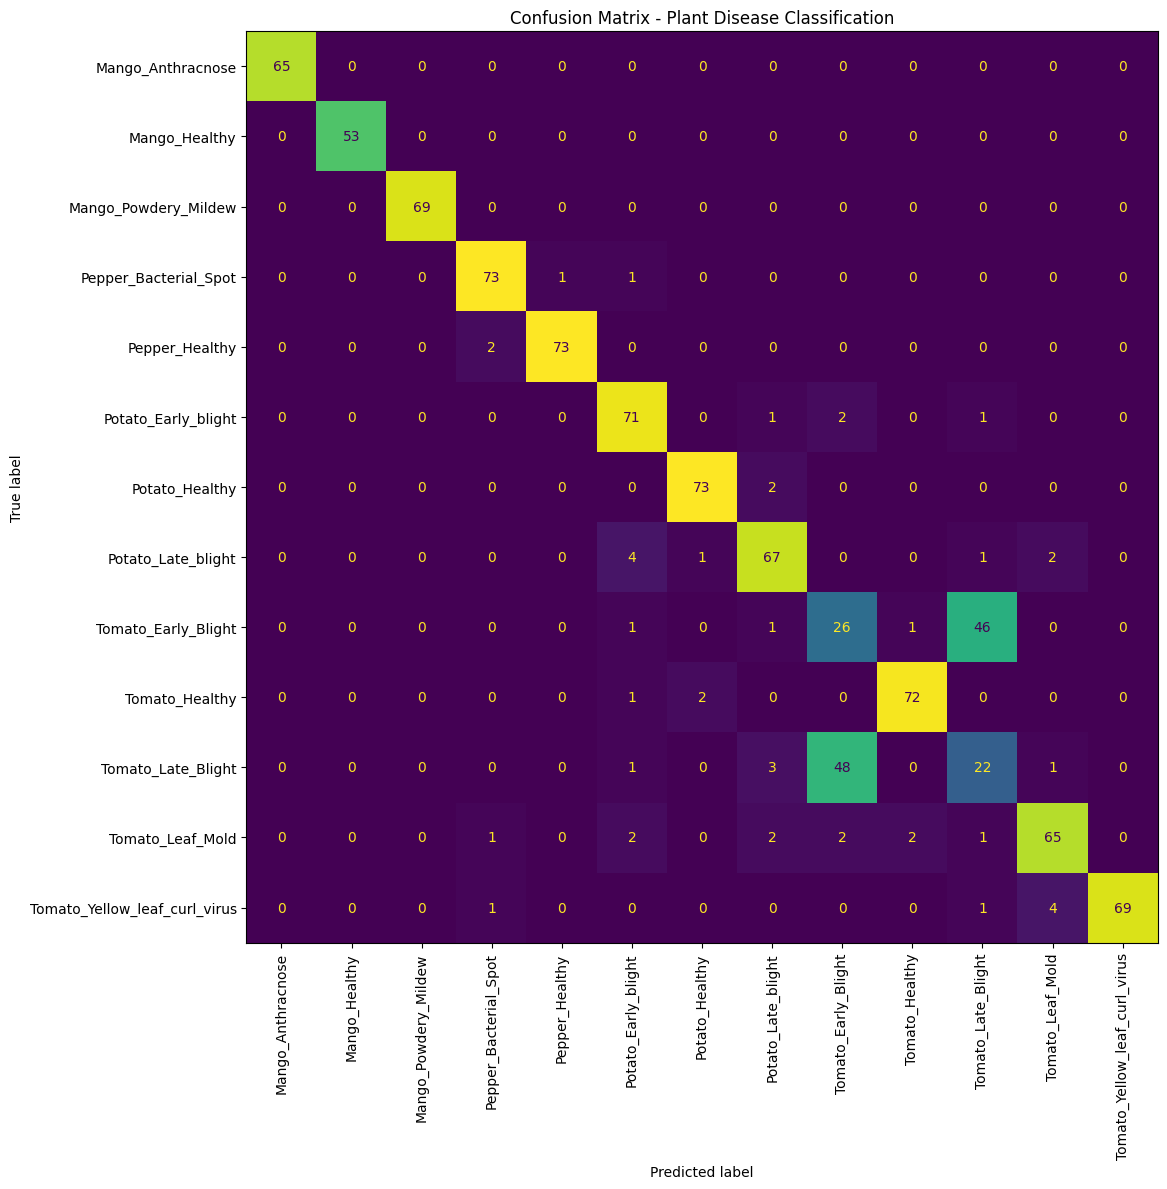

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

# LOAD BEST MODEL
model = load_model("models/best_stage1_model.keras")

# GET TRUE LABELS
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

# GET PREDICTIONS
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# CLASS NAMES
with open("models/class_names.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]
print("Classes:", class_names)

# CLASSIFICATION REPORT
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report:\n")
print(report)

# Optional: save report to a text file
with open("models/classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, values_format="d", colorbar=False)
plt.title("Confusion Matrix - Plant Disease Classification")
plt.tight_layout()
plt.show()

# Optional: save confusion matrix image
fig.savefig("models/confusion_matrix.png", dpi=300, bbox_inches="tight")

The final model achieved an overall test accuracy of 85.6%, indicating good multi-class classification performance across 13 plant–disease categories. Performance was strongest for visually distinct classes such as mango diseases, pepper classes, potato healthy leaves, tomato healthy leaves, and tomato yellow leaf curl virus, all of which achieved high precision and recall. The main source of error occurred between tomato early blight and tomato late blight, which showed substantially lower F1-scores. This suggests that the model finds these classes more difficult to separate, likely due to visual similarity in leaf symptom patterns. Overall, the results confirm that the proposed approach is effective, while also highlighting the challenge of distinguishing closely related disease classes.

### Modified classes for Tomato_Early_Blight and Tomato_Late_Blight

30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 432ms/step
Classes: ['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_blight', 'Potato_Healthy', 'Potato_Late_blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']

Classification Report:

                               precision    recall  f1-score   support

            Mango_Anthracnose     1.0000    1.0000    1.0000        65
                Mango_Healthy     1.0000    1.0000    1.0000        53
         Mango_Powdery_Mildew     1.0000    1.0000    1.0000        69
        Pepper_Bacterial_Spot     0.8987    0.9467    0.9221        75
               Pepper_Healthy     0.9859    0.9333    0.9589        75
          Potato_Early_blight     0.8043    0.9867    0.8862        75
               Potato_Healthy     0.9610    0.9867    0.9737        75
           Potato_Late_blight     0.9531    0.8133    0.8777        75

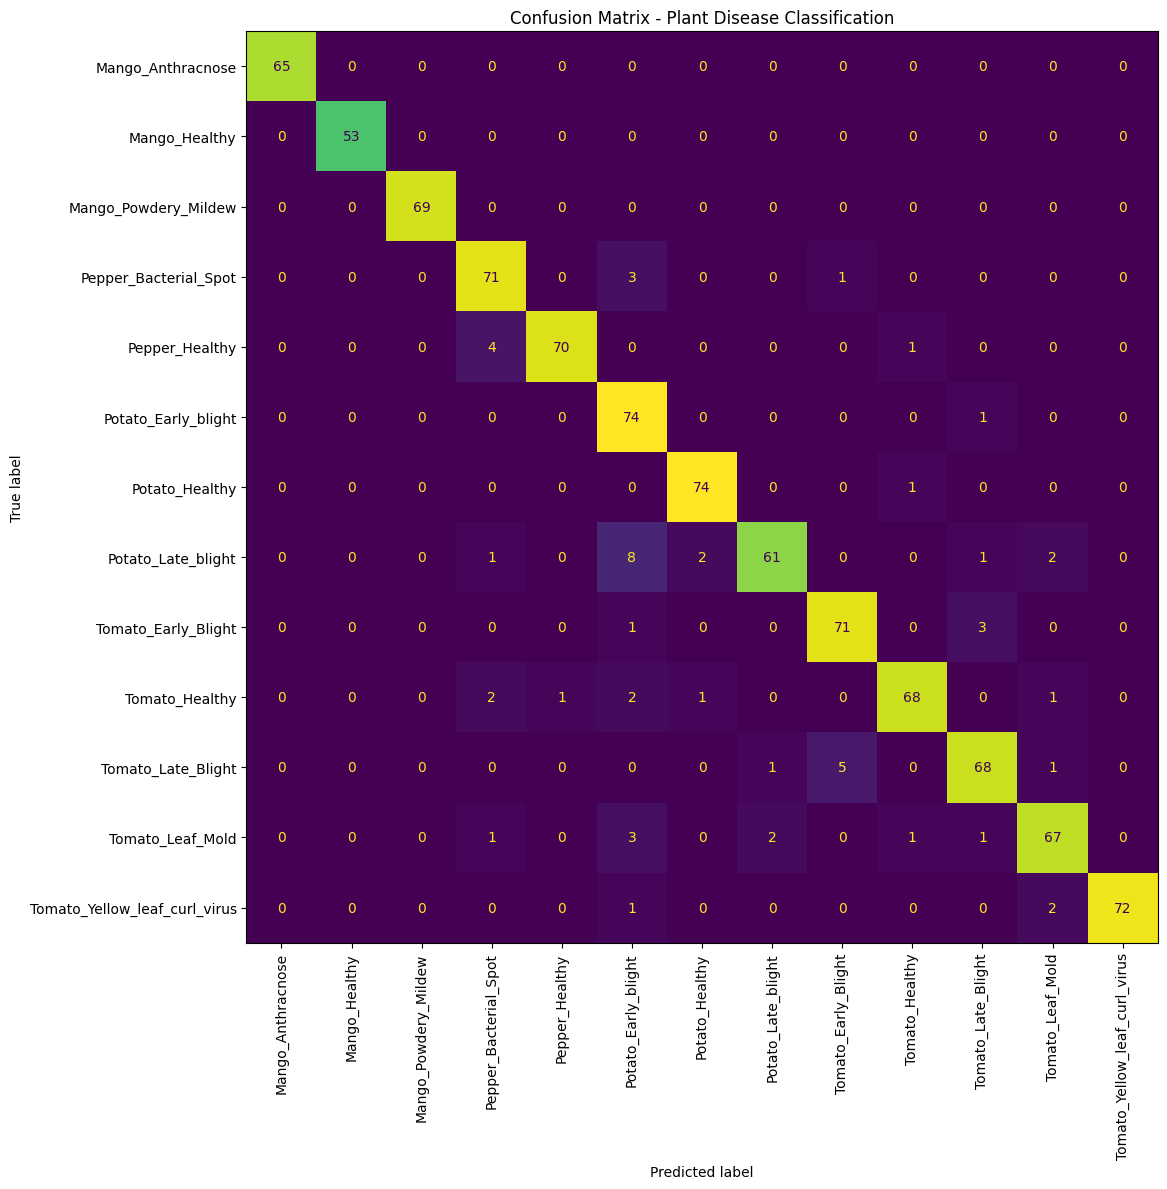

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

# LOAD BEST MODEL
model = load_model("models/best_stage1_model2.keras")

# GET TRUE LABELS
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

# GET PREDICTIONS
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# CLASS NAMES
with open("models/class_names.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]
print("Classes:", class_names)

# CLASSIFICATION REPORT
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report:\n")
print(report)

# Optional: save report to a text file
with open("models/classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, values_format="d", colorbar=False)
plt.title("Confusion Matrix - Plant Disease Classification")
plt.tight_layout()
plt.show()

# Optional: save confusion matrix image
fig.savefig("models/confusion_matrix.png", dpi=300, bbox_inches="tight")

After refining the dataset composition, particularly for the tomato blight classes, the final model achieved an overall test accuracy of 94.24% across 13 plant–disease classes. The weighted F1-score reached 0.9425, indicating strong and balanced classification performance. Performance was especially high for mango diseases, tomato yellow leaf curl virus, and healthy leaf classes. Importantly, the earlier confusion between tomato early blight and tomato late blight was substantially reduced, with both classes achieving F1-scores above 0.91. This demonstrates that the main source of previous error was dataset composition rather than inherent visual indistinguishability of the diseases.

A controlled binary experiment on PlantVillage tomato blight images confirmed that early blight and late blight were visually separable. Based on this finding, the tomato blight classes in the final multi-class dataset were reconstructed using cleaner and more consistent samples, which led to a substantial improvement in the final confusion matrix and overall model performance.